# Exploratory Data Analysis (EDA)

---
## 1. Setup & Data Loading

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Figure size defaults
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


In [5]:
# Load the dataset
df = pd.read_csv('Access_to_Care_Dataset.csv')

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Dataset loaded: 26,208 rows × 25 columns
Memory usage: 19.3 MB


---
## 2. Data Inspection

In [6]:
df.head()

,TOPIC,SUBTOPIC,SUBTOPIC_ID,TAXONOMY,TAXONOMY_ID,CLASSIFICATION,CLASSIFICATION_ID,GROUP,GROUP_ID,GROUP_ORDER,SUBGROUP,SUBGROUP_ID,SUBGROUP_ORDER,NESTING_LABEL,NESTING_LABEL_ID,ESTIMATE_TYPE,ESTIMATE_TYPE_ID,TIME_PERIOD,TIME_PERIOD_ID,ESTIMATE,STANDARD_ERROR,ESTIMATE_LCI,ESTIMATE_UCI,FLAG,FOOTNOTE_ID_LIST
0,Angina/angina pectoris,NaN,NaN,Cardiovascular diseases,60,Total,0,Total,1,1,18 years and older,1,1,NaN,NaN,"Percent of population, crude",1,2019,NaN,1.7,NaN,1.5,1.9,NaN,"NT_NHISA00,NT_NHISA999,FN_NHISA18,SC_NHISA00"
1,Angina/angina pectoris,NaN,NaN,Cardiovascular diseases,60,Total,0,Total,1,1,18 years and older,1,1,NaN,NaN,"Percent of population, crude",1,2020,NaN,1.5,NaN,1.3,1.6,NaN,"NT_NHISA00,NT_NHISA999,FN_NHISA18,SC_NHISA00"
2,Angina/angina pectoris,NaN,NaN,Cardiovascular diseases,60,Total,0,Total,1,1,18 years and older,1,1,NaN,NaN,"Percent of population, crude",1,2021,NaN,1.5,NaN,1.4,1.7,NaN,"NT_NHISA00,NT_NHISA999,FN_NHISA18,SC_NHISA00"
3,Angina/angina pectoris,NaN,NaN,Cardiovascular diseases,60,Total,0,Total,1,1,18 years and older,1,1,NaN,NaN,"Percent of population, crude",1,2022,NaN,1.6,NaN,1.5,1.8,NaN,"NT_NHISA00,NT_NHISA999,FN_NHISA18,SC_NHISA00"
4,Angina/angina pectoris,NaN,NaN,Cardiovascular diseases,60,Total,0,Total,1,1,18 years and older,1,1,NaN,NaN,"Percent of population, crude",1,2023,NaN,1.6,NaN,1.4,1.8,NaN,"NT_NHISA00,NT_NHISA999,FN_NHISA18,SC_NHISA00"


In [7]:
print("=" * 80)
print("Data Types and Missing Values")
print("=" * 80)

info_df = pd.DataFrame({
    'Column': df.columns,
    'Type': df.dtypes.values,
    'Non-Null': df.count().values,
    'Null': df.isnull().sum().values,
    'Null %': (df.isnull().sum() / len(df) * 100).round(2).values,
    'Unique': [df[col].nunique() for col in df.columns]
})

print(info_df.to_string(index=False))

Data Types and Missing Values
           Column    Type  Non-Null  Null  Null %  Unique
            TOPIC  object     26208     0    0.00      54
         SUBTOPIC  object      1404 24804   94.64       3
      SUBTOPIC_ID float64      1404 24804   94.64       3
         TAXONOMY  object     26208     0    0.00      19
      TAXONOMY_ID   int64     26208     0    0.00      19
   CLASSIFICATION  object     26208     0    0.00       4
CLASSIFICATION_ID   int64     26208     0    0.00       4
            GROUP  object     26208     0    0.00      21
         GROUP_ID   int64     26208     0    0.00      21
      GROUP_ORDER   int64     26208     0    0.00      21
         SUBGROUP  object     26208     0    0.00      75
      SUBGROUP_ID   int64     26208     0    0.00      78
   SUBGROUP_ORDER   int64     26208     0    0.00      78
    NESTING_LABEL  object      2016 24192   92.31       2
 NESTING_LABEL_ID float64      2016 24192   92.31       2
    ESTIMATE_TYPE  object     26208     0 

In [8]:
# Statistical summary of numerical columns
df.describe()

,SUBTOPIC_ID,TAXONOMY_ID,CLASSIFICATION_ID,GROUP_ID,GROUP_ORDER,SUBGROUP_ID,SUBGROUP_ORDER,NESTING_LABEL_ID,ESTIMATE_TYPE_ID,TIME_PERIOD,TIME_PERIOD_ID,ESTIMATE,STANDARD_ERROR,ESTIMATE_LCI,ESTIMATE_UCI
count,1404.000000,26208.000000,26208.000000,26208.000000,26208.000000,26208.000000,26208.000000,2016.000000,26208.0,26208.000000,0.0,23839.000000,0.0,23633.000000,23633.000000
mean,2.000000,134.732143,1.769231,11.820513,11.820513,39.500000,39.500000,15.000000,1.0,2021.500000,NaN,21.884232,NaN,20.667863,23.601011
std,0.816788,68.449798,0.890466,5.887395,5.887395,22.515239,22.515239,5.001241,0.0,1.707858,NaN,23.938021,NaN,23.556541,24.360457
min,1.000000,10.000000,0.000000,1.000000,1.000000,1.000000,1.000000,10.000000,1.0,2019.000000,NaN,0.000000,NaN,0.000000,0.000000
25%,1.000000,85.000000,1.000000,7.000000,7.000000,20.000000,20.000000,10.000000,1.0,2020.000000,NaN,5.600000,NaN,5.000000,6.700000
50%,2.000000,120.000000,1.000000,12.000000,12.000000,39.500000,39.500000,15.000000,1.0,2021.500000,NaN,12.600000,NaN,11.400000,14.300000
75%,3.000000,177.500000,3.000000,17.000000,17.000000,59.000000,59.000000,20.000000,1.0,2023.000000,NaN,26.700000,NaN,24.900000,29.500000
max,3.000000,270.000000,3.000000,21.000000,21.000000,78.000000,78.000000,20.000000,1.0,2024.000000,NaN,100.000000,NaN,100.000000,100.000000


---
## 3. Data Cleaning
Based on initial data inspection, the following columns were deemed essential or at least useful and kept in the cleaned dataframe:  
* TOPIC: Essential - Core filtering variable for all analysis  
* TAXONOMY: Useful - Organizational value for visualizations and reports  
* CLASSIFICATION: Essential - Prevent mixing overlaping populations and understand what level of detail you're looking at  
* GROUP: Very Useful - Understand relationships between subgroups, comparison organization  
* SUBGROUP: Essential - Specifies exactly which population is being measured  
* TIME_PERIOD: Essential - Enables temporal analysis  
* ESTIMATE: Essential - Target variable  
* ESTIMATE_LCI: Essential - For statistical rigor, determines if differences are meaningful or just noise  
* ESTIMATE_UCI: Essential - For statistical rigor, determines if differences are meaningful or just noise   
  
The other 16 were removed. These included empty or single-unique-value columns, redundant ID columns, display sorting columns, and sparse data columns.





In [9]:
# Keep only essential columns for analysis
essential_cols = [
    'TOPIC', 'TAXONOMY', 'CLASSIFICATION', 'GROUP', 'SUBGROUP',
    'TIME_PERIOD', 'ESTIMATE', 'ESTIMATE_LCI', 'ESTIMATE_UCI'
]
df = df[essential_cols]
print(f"Kept {len(essential_cols)} essential columns for analysis")

Kept 9 essential columns for analysis


ESTIMATE is the target variable, i.e. it is the most important piece of information. Therefore, rows that are missing this value are eliminated. This reduces the dataset by 9%, which is acceptable. The remaining data is a sufficient quantity for analysis.

In [10]:
# Remove rows where ESTIMATE is missing
before_count = len(df)
df = df.dropna(subset=['ESTIMATE'])
removed = before_count - len(df)
print(f"Removed {removed:,} rows with missing ESTIMATE values ({removed/before_count*100:.1f}%)")

Removed 2,369 rows with missing ESTIMATE values (9.0%)


Data type optimization was performed to save memory.
*   int64->int16: saves 75% memory, and is more than sufficient to store year
*   float64->float32: saves 50% memory, and is more than sufficient to store data that is only reported to 1 decimal place



In [11]:
# Data type optimization
df['TIME_PERIOD'] = df['TIME_PERIOD'].astype('int16')
df['ESTIMATE'] = df['ESTIMATE'].astype('float32')
df['ESTIMATE_LCI'] = df['ESTIMATE_LCI'].astype('float32')
df['ESTIMATE_UCI'] = df['ESTIMATE_UCI'].astype('float32')

In [12]:
# Check for duplicates
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"Found {duplicates} duplicate rows")
    df = df.drop_duplicates()
    print(f"Removed duplicates")
else:
    print("No duplicate rows found")

No duplicate rows found


In [13]:
# Access barriers only
access_topics = [
    'Delayed getting medical care due to cost among adults',
    'Did not get needed medical care due to cost',
    'Did not get needed mental health care due to cost',
    'Did not take medication as prescribed to save money',
    # 'Has a usual place of care among adults'
]
df = df[df['TOPIC'].isin(access_topics)].copy()

In [14]:
print("\n" + "=" * 80)
print(f"FINAL CLEANED DATASET: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print("=" * 80)


FINAL CLEANED DATASET: 1,807 rows × 9 columns
Memory usage: 0.7 MB


In [15]:
df.head()

,TOPIC,TAXONOMY,CLASSIFICATION,GROUP,SUBGROUP,TIME_PERIOD,ESTIMATE,ESTIMATE_LCI,ESTIMATE_UCI
9360,Delayed getting medical care due to cost among...,Healthcare access and quality,Total,Total,18 years and older,2019,9.1,8.6,9.5
9361,Delayed getting medical care due to cost among...,Healthcare access and quality,Total,Total,18 years and older,2020,7.5,7.1,8.0
9362,Delayed getting medical care due to cost among...,Healthcare access and quality,Total,Total,18 years and older,2021,7.1,6.8,7.5
9363,Delayed getting medical care due to cost among...,Healthcare access and quality,Total,Total,18 years and older,2022,7.0,6.6,7.4
9364,Delayed getting medical care due to cost among...,Healthcare access and quality,Total,Total,18 years and older,2023,7.2,6.8,7.6


In [16]:
df = df.sort_values(["TOPIC", "SUBGROUP", "TIME_PERIOD"])

In [19]:
def make_features(data):

    data = data.copy()

    g = data.groupby(["TOPIC", "SUBGROUP"])

    data["lag1"] = g["ESTIMATE"].shift(1)
    data["lag2"] = g["ESTIMATE"].shift(2)

    data["mean3"] = g["ESTIMATE"].transform(
        lambda x: x.rolling(3).mean()
    )

    data["diff1"] = g["ESTIMATE"].diff(1)

    return data

In [20]:
df_feat = make_features(df)

df_feat = df_feat.dropna()

In [21]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in ["TOPIC", "GROUP", "SUBGROUP"]:
    le = LabelEncoder()
    df_feat[col] = le.fit_transform(df_feat[col])
    encoders[col] = le

In [22]:
train_2023 = df_feat[df_feat["TIME_PERIOD"] <= 2023]
test_2024  = df_feat[df_feat["TIME_PERIOD"] == 2024]

In [23]:
features = [
    "TOPIC",
    "GROUP",
    "SUBGROUP",
    "TIME_PERIOD",
    "lag1",
    "lag2",
    "mean3",
    "diff1"
]

X_train = train_2023[features]
y_train = train_2023["ESTIMATE"]

X_test = test_2024[features]
y_test = test_2024["ESTIMATE"]

In [24]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [25]:
from sklearn.metrics import mean_squared_error, r2_score
pred_2024 = rf.predict(X_test)

rmse_2024 = np.sqrt(mean_squared_error(y_test, pred_2024))
r2_2024 = r2_score(y_test, pred_2024)

rmse_2024, r2_2024

(np.float64(0.793891520126051), 0.9554059008184754)

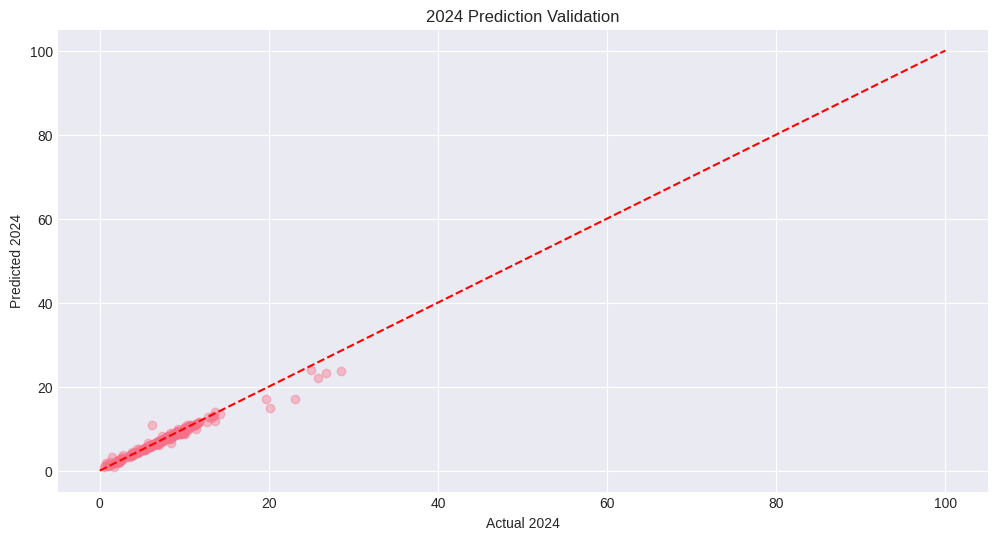

In [26]:
import matplotlib.pyplot as plt
plt.scatter(y_test, pred_2024, alpha=0.4)
plt.plot([0,100],[0,100],'r--')
plt.xlabel("Actual 2024")
plt.ylabel("Predicted 2024")
plt.title("2024 Prediction Validation")
plt.show()

In [27]:
train_2024 = df_feat[df_feat["TIME_PERIOD"] <= 2024]

X_full = train_2024[features]
y_full = train_2024["ESTIMATE"]

rf_final = RandomForestRegressor(
    n_estimators=400,
    max_depth=14,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_full, y_full)

RandomForestRegressor(max_depth=14, n_estimators=400, n_jobs=-1,
                      random_state=42)

In [28]:
last_year = df_feat[df_feat["TIME_PERIOD"] == 2024].copy()

last_year["TIME_PERIOD"] = 2025

last_year["lag2"] = last_year["lag1"]
last_year["lag1"] = last_year["ESTIMATE"]

last_year["mean3"] = (
    last_year[["lag1","lag2","mean3"]].mean(axis=1)
)

last_year["diff1"] = last_year["lag1"] - last_year["lag2"]

In [29]:
X_2025 = last_year[features]

pred_2025 = rf_final.predict(X_2025)

last_year["Predicted_2025"] = pred_2025

In [30]:
last_year[[
    "TOPIC",
    "SUBGROUP",
    "Predicted_2025"
]].head(10)

,TOPIC,SUBGROUP,Predicted_2025
9821,0,0,11.624489
9365,0,1,8.874722
9371,0,2,11.039312
9395,0,3,10.990937
9377,0,4,11.192406
9401,0,5,10.585768
9383,0,6,9.884937
9389,0,7,2.607354
9407,0,8,3.493083
9413,0,9,1.628888


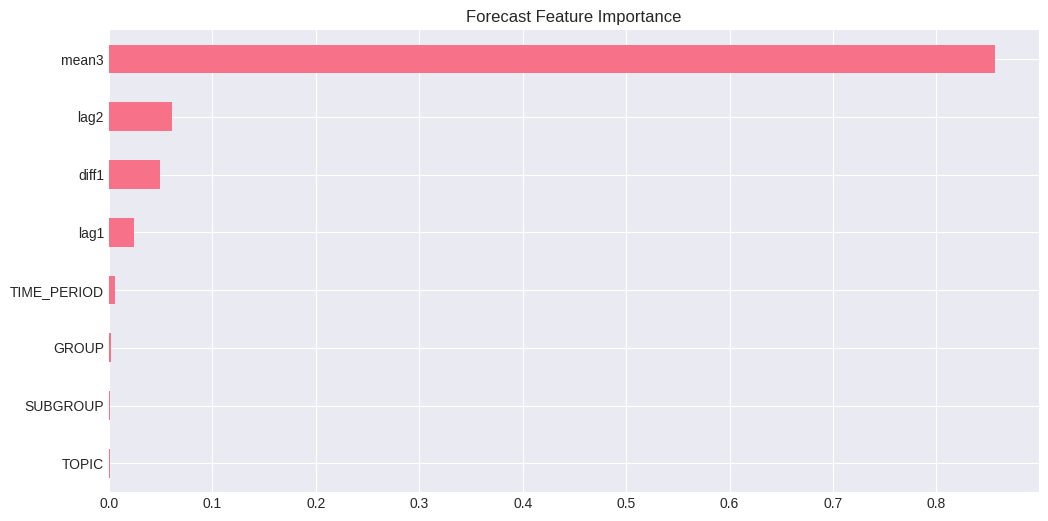

In [31]:
importances = pd.Series(
    rf_final.feature_importances_,
    index=features
).sort_values()

importances.plot(kind="barh")
plt.title("Forecast Feature Importance")
plt.show()